# **«Гибридное прогнозирование волатильности с учётом структурных сдвигов: сравнение методов ICSS, KL и KS в GARCH-моделях с LSTM-коррекцией (на примере индексов S&P 500 и IMOEX, 2018–2025)»**

In [ ]:
#!pip install yfinance arch tensorflow scikit-learn scipy pandas numpy matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import yfinance as yf
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
N_CLUSTERS = 3

## Загрузка и подготовка данных.

In [ ]:
def load_ticker(ticker, start, end):

    """
    Загружает данные с Yahoo Finance и вычисляет доходности и квадраты доходностей.

    Parameters
    ----------
    ticker : str
        Тикер инструмента (например, '^GSPC').
    start : str
        Дата начала в формате 'YYYY-MM-DD'.
    end : str
        Дата окончания.

    Returns
    -------
    pd.DataFrame
        DataFrame с колонками 'returns' (доходности, %) и 'actual_vol' (квадраты доходностей).
    """

    data = yf.download(ticker, start=start, end=end, progress=False)
    if data.empty:
        raise ValueError(f"Нет данных для {ticker}")
    close = data['Close'].iloc[:, 0]
    returns = 100 * np.log(close / close.shift(1)).dropna()
    vol = returns ** 2
    return pd.DataFrame({'returns': returns, 'actual_vol': vol})

## Программная реализация методов обнаружения структурных сдвигов

### ICSS

In [ ]:
def icss_detect(series, threshold=1.358):

    """
    ICSS – обнаружение сдвигов дисперсии.

    Parameters
    ----------
    series : pd.Series
        Квадраты доходностей.
    threshold : float, default=1.358
        Критическое значение для уровня значимости 0.05.

    Returns
    -------
    list
        Список индексов (позиций) обнаруженных сдвигов.
    """

    y = series.values
    n = len(y)

    def _rec(start, end):
        if end - start < 10:
            return []
        sub = y[start:end]
        C = np.cumsum(sub)
        C_total = C[-1]
        if C_total == 0:
            return []
        D = np.zeros(len(sub))
        for k in range(1, len(sub)):
            D[k] = abs(C[k-1] - (k/len(sub))*C_total) / np.sqrt(C_total * (k/len(sub))*(1 - k/len(sub)))
        maxD = np.max(D)
        if maxD > threshold:
            pos = np.argmax(D)
            global_pos = start + pos
            left = _rec(start, global_pos)
            right = _rec(global_pos, end)
            return left + [global_pos] + right
        return []

    cp = _rec(0, n)
    cp = sorted(set(cp))
    merged = []
    for p in cp:
        if not merged or p - merged[-1] > 5:
            merged.append(p)
    return merged

### KL

In [ ]:
def kl_statistic(y, k):

    """
    Вспомогательная статистика для KL-критерия.

    Parameters
    ----------
    y : np.ndarray
        Массив квадратов доходностей.
    k : int
        Потенциальная точка сдвига.

    Returns
    -------
    float
        Значение KL-статистики.
    """

    n = len(y)
    if k < 10 or k > n-10:
        return 0
    var1 = np.var(y[:k])
    var2 = np.var(y[k:])
    var_full = np.var(y)
    if var_full == 0:
        return 0
    return np.sqrt(k*(n-k)/n) * abs(var1 - var2) / var_full

def kl_detect(series, threshold=1.36):

    """
    KL-ICSS (Kokoszka–Leipus) – обнаружение сдвигов.

    Parameters
    ----------
    series : pd.Series
        Квадраты доходностей.
    threshold : float, default=1.36
        Пороговое значение.

    Returns
    -------
    list
        Список индексов сдвигов.
    """

    y = series.values
    n = len(y)

    def _rec(start, end):
        if end - start < 20:
            return []
        sub = y[start:end]
        best_k = -1
        best_stat = 0
        for k in range(10, len(sub)-10):
            stat = kl_statistic(sub, k)
            if stat > best_stat:
                best_stat = stat
                best_k = k
        if best_stat > threshold and best_k != -1:
            global_pos = start + best_k
            left = _rec(start, global_pos)
            right = _rec(global_pos, end)
            return left + [global_pos] + right
        return []

    cp = _rec(0, n)
    return sorted(set(cp))

### KS

In [ ]:
def ks_two_sample(s1, s2):

    """
    Двухвыборочная статистика Колмогорова–Смирнова.

    Parameters
    ----------
    s1, s2 : np.ndarray
        Две выборки.

    Returns
    -------
    float
        KS-статистика (максимальное расстояние между эмпирическими функциями распределения).
    """

    all_vals = np.concatenate([s1, s2])
    ecdf1 = np.array([np.mean(s1 <= x) for x in all_vals])
    ecdf2 = np.array([np.mean(s2 <= x) for x in all_vals])
    return np.max(np.abs(ecdf1 - ecdf2))

def ks_detect(series, min_seg=20):

    """
    KS-ICSS – обнаружение сдвигов на основе теста Колмогорова–Смирнова.

    Parameters
    ----------
    series : pd.Series
        Квадраты доходностей.
    min_seg : int, default=20
        Минимальная длина сегмента для поиска.

    Returns
    -------
    list
        Список индексов сдвигов.
    """

    y = series.values
    n = len(y)

    def _rec(start, end):
        if end - start < 2*min_seg:
            return []
        best_k = -1
        best_stat = 0
        for k in range(start+min_seg, end-min_seg):
            stat = ks_two_sample(y[start:k], y[k:end])
            if stat > best_stat:
                best_stat = stat
                best_k = k
        threshold = 1.36 / np.sqrt((end-start)/2)
        if best_stat > threshold and best_k != -1:
            left = _rec(start, best_k)
            right = _rec(best_k, end)
            return left + [best_k] + right
        return []

    cp = _rec(0, n)
    return sorted(set(cp))

### Аггрегация обнаруженных сдвигов

In [ ]:
def aggregate_cp(cp_list, n_clusters=N_CLUSTERS):

    """
    Агрегирует множество точек сдвигов в n_clusters кластеров с помощью KMeans.

    Parameters
    ----------
    cp_list : list
        Список сырых индексов сдвигов.
    n_clusters : int, default=3
        Число кластеров.

    Returns
    -------
    list
        Отсортированные центры кластеров (агрегированные сдвиги).
    """

    if len(cp_list) <= n_clusters:
        return cp_list
    X = np.array(cp_list).reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    kmeans.fit(X)
    centers = np.sort(kmeans.cluster_centers_.flatten().astype(int))
    return centers.tolist()

## Модель GARCH с dummy-переменными

In [ ]:
def garch11_dummy_ll(params, returns, dummies):

    """
    Логарифмическое правдоподобие GARCH(1,1) с фиктивными переменными в дисперсии.

    Parameters
    ----------
    params : list
        Параметры [ω, α, β, γ₁, γ₂, ...].
    returns : np.ndarray
        Доходности.
    dummies : pd.DataFrame
        Фиктивные переменные (одна колонка на сдвиг).

    Returns
    -------
    float
        Отрицательное логарифмическое правдоподобие.
    """

    omega, alpha, beta = params[:3]
    gamma = params[3:]
    T = len(returns)
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)
    ll = 0.0
    for t in range(1, T):
        de = np.sum(gamma * dummies.iloc[t].values)
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1] + de
        if sigma2[t] <= 1e-8:
            return 1e10
        ll += -0.5 * (np.log(2*np.pi) + np.log(sigma2[t]) + returns[t]**2 / sigma2[t])
    return -ll

def estimate_garch_dummy(returns, cp_indices):

    """
    Оценивает GARCH(1,1) с фиктивными переменными (дамми) на основе индексов сдвигов.

    Parameters
    ----------
    returns : np.ndarray
        Доходности.
    cp_indices : list
        Список агрегированных индексов сдвигов.

    Returns
    -------
    sigma2 : np.ndarray
        Условная дисперсия на весь ряд.
    opt : tuple or None
        Оптимальные параметры (ω, α, β, γ) или None, если использована базовая GARCH.
    """

    T = len(returns)
    dummies = pd.DataFrame(index=np.arange(T))
    for i, cp in enumerate(cp_indices):
        dummies[f'D{i+1}'] = (np.arange(T) >= cp).astype(int)
    init = [0.05, 0.1, 0.8] + [0.1] * len(cp_indices)
    bounds = [(1e-6, None), (1e-6, 1), (1e-6, 1)] + [(None, None)] * len(cp_indices)
    res = minimize(garch11_dummy_ll, init, args=(returns, dummies), method='L-BFGS-B',
                   bounds=bounds, options={'maxiter': 200})
    if not res.success:
        # fallback: базовая GARCH
        model = arch_model(pd.Series(returns), vol='Garch', p=1, q=1, dist='normal')
        resm = model.fit(disp='off')
        sigma2 = resm.conditional_volatility ** 2
        return sigma2, None
    opt = res.x
    omega, alpha, beta = opt[:3]
    gamma = opt[3:]
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)
    for t in range(1, T):
        de = np.sum(gamma * dummies.iloc[t].values)
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1] + de
        if sigma2[t] <= 0:
            sigma2[t] = 1e-6
    return sigma2, opt

## LSTM для коррекции ошибок

In [ ]:
def build_lstm(timesteps, n_features):

    """
    Строит модель LSTM с двумя слоями и dropout.

    Parameters
    ----------
    timesteps : int
        Длина окна (lookback).
    n_features : int
        Количество признаков (должно быть 3).

    Returns
    -------
    keras.Model
        Скомпилированная модель LSTM.
    """

    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(timesteps, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def prepare_lstm_data(errors, actual_vol, returns, lookback=10):

    """
    Формирует матрицы X (признаки) и y (целевая переменная) для LSTM.

    Parameters
    ----------
    errors : pd.Series
        Ошибки GARCH-dummy.
    actual_vol : pd.Series
        Фактическая волатильность (квадраты доходностей).
    returns : pd.Series
        Доходности.
    lookback : int, default=10
        Длина окна.

    Returns
    -------
    X : np.ndarray
        Матрица признаков (число примеров, lookback*3).
    y : np.ndarray
        Вектор целевых значений (ошибка на следующий день).
    """

    X, y = [], []
    for i in range(lookback, len(errors)-1):
        feat = []
        for lag in range(1, lookback+1):
            feat.append(errors.iloc[i-lag])
            feat.append(actual_vol.iloc[i-lag])
            feat.append(returns.iloc[i-lag]**2)
        X.append(feat)
        y.append(errors.iloc[i+1])
    return np.array(X), np.array(y)

def train_lstm(train_errors, train_actual, train_returns, lookback=10, use_tqdm=True):

    """
    Обучает LSTM на ошибках GARCH-dummy.

    Parameters
    ----------
    train_errors : pd.Series
        Ошибки на обучающей выборке.
    train_actual : pd.Series
        Фактическая волатильность на обучении.
    train_returns : pd.Series
        Доходности на обучении.
    lookback : int, default=10
        Длина окна.
    use_tqdm : bool, default=True
        Показывать прогресс-бар tqdm.

    Returns
    -------
    model : keras.Model
        Обученная модель LSTM.
    scaler_X : sklearn MinMaxScaler
        Нормализатор для признаков.
    scaler_y : sklearn MinMaxScaler
        Нормализатор для целевой переменной.
    """

    X, y = prepare_lstm_data(train_errors, train_actual, train_returns, lookback)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten()
    X_reshaped = X_scaled.reshape(-1, lookback, 3)
    model = build_lstm(lookback, 3)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    if use_tqdm:
        class TqdmCallback(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                pbar.set_postfix(loss=logs['loss'], val_loss=logs['val_loss'])
                pbar.update(1)
        with tqdm(total=50, desc="Обучение LSTM", unit="epoch") as pbar:
            history = model.fit(X_reshaped, y_scaled,
                                epochs=50, batch_size=32, validation_split=0.1,
                                callbacks=[early_stop, TqdmCallback()], verbose=0)
    else:
        model.fit(X_reshaped, y_scaled, epochs=50, batch_size=32, validation_split=0.1,
                  callbacks=[early_stop], verbose=0)
    return model, scaler_X, scaler_y

def predict_lstm(model, scaler_X, scaler_y, test_errors, test_actual, test_returns, lookback=10):

    """
    Прогнозирует ошибки на тестовой выборке с помощью обученного LSTM.

    Parameters
    ----------
    model : keras.Model
        Обученная модель.
    scaler_X, scaler_y : sklearn MinMaxScaler
        Нормализаторы.
    test_errors : pd.Series
        Ошибки на тесте.
    test_actual : pd.Series
        Фактическая волатильность на тесте.
    test_returns : pd.Series
        Доходности на тесте.
    lookback : int, default=10
        Длина окна.

    Returns
    -------
    pred : np.ndarray
        Предсказанные ошибки.
    y_true : np.ndarray
        Истинные ошибки (для проверки).
    """

    X_test, y_true = prepare_lstm_data(test_errors, test_actual, test_returns, lookback)
    if len(X_test) == 0:
        return np.array([]), np.array([])
    X_scaled = scaler_X.transform(X_test)
    X_reshaped = X_scaled.reshape(-1, lookback, 3)
    pred_scaled = model.predict(X_reshaped, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled).flatten()
    return pred, y_true

## Реализация функций для одного тикера и метода

In [ ]:
def evaluate_method(df_train, df_test, method_name, detect_func, lookback=10):

    """
    Выполняет полный цикл: обнаружение сдвигов, GARCH-dummy, LSTM и метрики.

    Parameters
    ----------
    df_train, df_test : pd.DataFrame
        Обучающая и тестовая выборки.
    method_name : str
        Название метода ('icss', 'kl', 'ks').
    detect_func : callable
        Функция обнаружения сдвигов (icss_detect, kl_detect, ks_detect).
    lookback : int, default=10
        Длина окна для LSTM.

    Returns
    -------
    results : dict
        Словарь с метриками для базовой GARCH, GARCH-dummy и гибрида.
    actual_aligned : np.ndarray
        Фактические значения волатильности на тесте (выровненные).
    base_aligned : np.ndarray
        Прогноз базовой GARCH (выровненный).
    dummy_aligned : np.ndarray
        Прогноз GARCH-dummy (выровненный).
    hybrid_aligned : np.ndarray or None
        Прогноз гибридной модели (если удалось обучить LSTM).
    test_dates : pd.Index
        Даты, соответствующие выровненным прогнозам.
    """

    print(f"\n--- Метод {method_name.upper()} ---")
    #Обнаружение сдвигов на train
    raw_cp = detect_func(df_train['actual_vol'])
    cp_indices = aggregate_cp(raw_cp, N_CLUSTERS)
    cp_dates = df_train.index[cp_indices].strftime('%Y-%m-%d').tolist()
    print(f"Сдвиги (индексы в train): {cp_indices}")
    print(f"Даты сдвигов: {cp_dates}")

    #Базовая GARCH
    base_model = arch_model(df_train['returns'], vol='Garch', p=1, q=1, dist='normal')
    base_res = base_model.fit(disp='off')
    forecast = base_res.forecast(horizon=len(df_test), start=len(df_train)-1)
    base_vol_test = forecast.variance.values[-1, :]

    #GARCH-dummy
    full_returns = np.concatenate([df_train['returns'].values, df_test['returns'].values])
    sigma2_dummy_full, _ = estimate_garch_dummy(full_returns, cp_indices)
    dummy_vol_test = sigma2_dummy_full[len(df_train):]

    #Ошибки
    train_vol = df_train['actual_vol'].values
    test_vol = df_test['actual_vol'].values
    train_errors = train_vol - sigma2_dummy_full[:len(df_train)]
    test_errors = test_vol - dummy_vol_test

    #LSTM коррекция
    if len(train_errors) > lookback+1 and len(test_errors) > lookback+1:
        try:
            model_lstm, scaler_X, scaler_y = train_lstm(
                pd.Series(train_errors), df_train['actual_vol'], df_train['returns'],
                lookback=lookback, use_tqdm=False)
            pred_errors, _ = predict_lstm(model_lstm, scaler_X, scaler_y,
                                          pd.Series(test_errors), df_test['actual_vol'],
                                          df_test['returns'], lookback=lookback)
            actual_aligned = test_vol[lookback+1:]
            base_aligned = base_vol_test[lookback+1:]
            dummy_aligned = dummy_vol_test[lookback+1:]
            hybrid_aligned = dummy_aligned + pred_errors
            test_dates = df_test.index[lookback+1:]
        except Exception as e:
            print(f"Ошибка LSTM: {e}, пропускаем гибридную модель")
            actual_aligned = test_vol[lookback+1:]
            base_aligned = base_vol_test[lookback+1:]
            dummy_aligned = dummy_vol_test[lookback+1:]
            hybrid_aligned = None
            test_dates = df_test.index[lookback+1:]
    else:
        print("Недостаточно данных для LSTM")
        actual_aligned = test_vol[lookback+1:]
        base_aligned = base_vol_test[lookback+1:]
        dummy_aligned = dummy_vol_test[lookback+1:]
        hybrid_aligned = None
        test_dates = df_test.index[lookback+1:]

    #Метрики
    def metrics(y_true, y_pred):
        return {
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred)
        }

    results = {
        'Базовая GARCH': metrics(actual_aligned, base_aligned),
        'GARCH-dummy': metrics(actual_aligned, dummy_aligned)
    }
    if hybrid_aligned is not None:
        results['Гибрид (GARCH-dummy+LSTM)'] = metrics(actual_aligned, hybrid_aligned)

    return results, actual_aligned, base_aligned, dummy_aligned, hybrid_aligned, test_dates

## Работа с тикерами

In [ ]:
start_date = '2018-01-01'
end_date   = '2025-04-01'

print("Загрузка S&P 500...")
df_spx = load_ticker('^GSPC', start_date, end_date)
print(df_spx.head())
print(f"Форма: {df_spx.shape}")

print("\nЗагрузка IMOEX...")
df_imoex = load_ticker('IMOEX.ME', start_date, end_date)
print(df_imoex.head())
print(f"Форма: {df_imoex.shape}")

split_spx = int(0.8 * len(df_spx))
split_imoex = int(0.8 * len(df_imoex))
train_spx = df_spx.iloc[:split_spx].copy()
test_spx  = df_spx.iloc[split_spx:].copy()
train_imoex = df_imoex.iloc[:split_imoex].copy()
test_imoex  = df_imoex.iloc[split_imoex:].copy()
print(f"\nS&P 500: train {len(train_spx)}, test {len(test_spx)}")
print(f"IMOEX:   train {len(train_imoex)}, test {len(test_imoex)}")

tickers = {
    'S&P 500': (train_spx, test_spx),
    'IMOEX': (train_imoex, test_imoex)
}
methods = {
    'icss': icss_detect,
    'kl': kl_detect,
    'ks': ks_detect
}

all_results = {}

for ticker_name, (tr, ts) in tickers.items():
    print(f"\n{'='*60}\nАнализ {ticker_name}\n{'='*60}")
    ticker_res = {}
    for method_name, detect_func in methods.items():
        res, act, base, dummy, hybrid, dates = evaluate_method(tr, ts, method_name, detect_func, lookback=10)
        ticker_res[method_name] = {
            'results': res,
            'actual': act,
            'base': base,
            'dummy': dummy,
            'hybrid': hybrid,
            'dates': dates
        }
    all_results[ticker_name] = ticker_res

Загрузка S&P 500...
             returns  actual_vol
Date                            
2018-01-03  0.637843    0.406844
2018-01-04  0.402054    0.161648
2018-01-05  0.700915    0.491281
2018-01-08  0.166096    0.027588
2018-01-09  0.130208    0.016954
Форма: (1820, 2)

Загрузка IMOEX...
             returns  actual_vol
Date                            
2018-01-04  2.051763    4.209731
2018-01-05  0.445394    0.198376
2018-01-09  0.811229    0.658093
2018-01-10  0.308688    0.095288
2018-01-11  0.633216    0.400962
Форма: (1592, 2)

S&P 500: train 1456, test 364
IMOEX:   train 1273, test 319

Анализ S&P 500

--- Метод ICSS ---
Сдвиги (индексы в train): [229, 635, 1118]
Даты сдвигов: ['2018-11-29', '2020-07-14', '2022-06-13']

--- Метод KL ---
Сдвиги (индексы в train): [252, 696, 1190]
Даты сдвигов: ['2019-01-04', '2020-10-08', '2022-09-26']

--- Метод KS ---
Сдвиги (индексы в train): [215, 642, 1134]
Даты сдвигов: ['2018-11-08', '2020-07-23', '2022-07-07']

Анализ IMOEX

--- Метод ICSS --

## Таблицы полученных результатов

In [ ]:
print("\n" + "="*40)
print("СВОДНАЯ ТАБЛИЦА: RMSE / MAE")
print("="*40)
for ticker_name, methods_dict in all_results.items():
    print(f"\n{ticker_name}:")
    for method_name, data in methods_dict.items():
        print(f"  Метод {method_name.upper()}:")
        for model_name, metrics_vals in data['results'].items():
            print(f"    {model_name:30} RMSE={metrics_vals['RMSE']:6.4f}  MAE={metrics_vals['MAE']:6.3f}")


СВОДНАЯ ТАБЛИЦА: RMSE / MAE

S&P 500:
  Метод ICSS:
    Базовая GARCH                  RMSE=1.7912  MAE= 1.637
    GARCH-dummy                    RMSE=1.2222  MAE= 0.797
    Гибрид (GARCH-dummy+LSTM)      RMSE=1.2519  MAE= 0.881
  Метод KL:
    Базовая GARCH                  RMSE=1.7912  MAE= 1.637
    GARCH-dummy                    RMSE=1.2208  MAE= 0.790
    Гибрид (GARCH-dummy+LSTM)      RMSE=1.2275  MAE= 0.695
  Метод KS:
    Базовая GARCH                  RMSE=1.7912  MAE= 1.637
    GARCH-dummy                    RMSE=1.2222  MAE= 0.797
    Гибрид (GARCH-dummy+LSTM)      RMSE=1.2192  MAE= 0.707

IMOEX:
  Метод ICSS:
    Базовая GARCH                  RMSE=8.3001  MAE= 7.326
    GARCH-dummy                    RMSE=1.1303  MAE= 0.786
    Гибрид (GARCH-dummy+LSTM)      RMSE=2.2287  MAE= 2.125
  Метод KL:
    Базовая GARCH                  RMSE=8.3001  MAE= 7.326
    GARCH-dummy                    RMSE=1.1304  MAE= 0.786
    Гибрид (GARCH-dummy+LSTM)      RMSE=1.1451  MAE= 0.895
  Ме

## Визуализация


Для S&P 500 лучший метод (GARCH-dummy): KL (RMSE=1.2208)


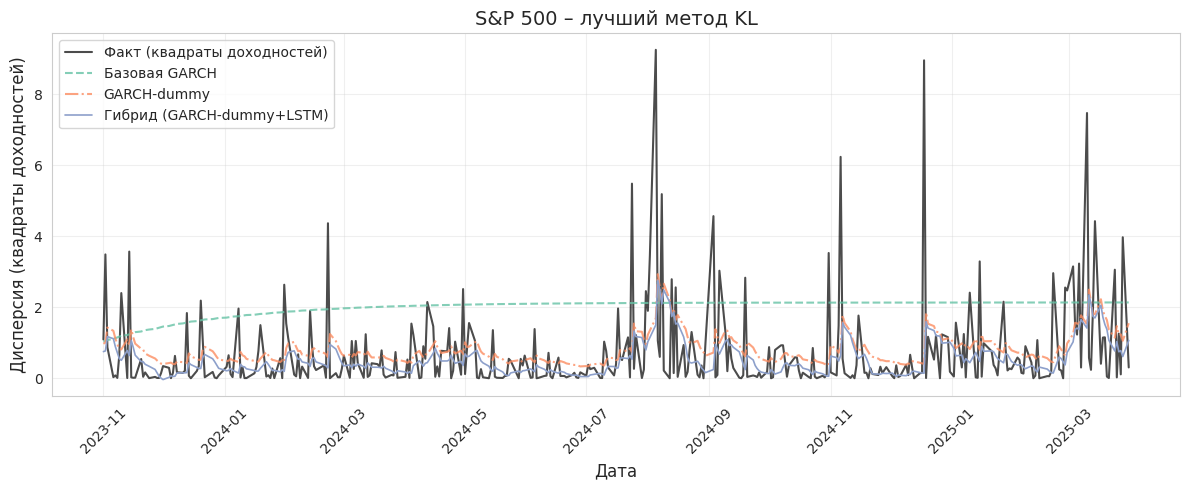


Для IMOEX лучший метод (GARCH-dummy): KS (RMSE=1.1297)


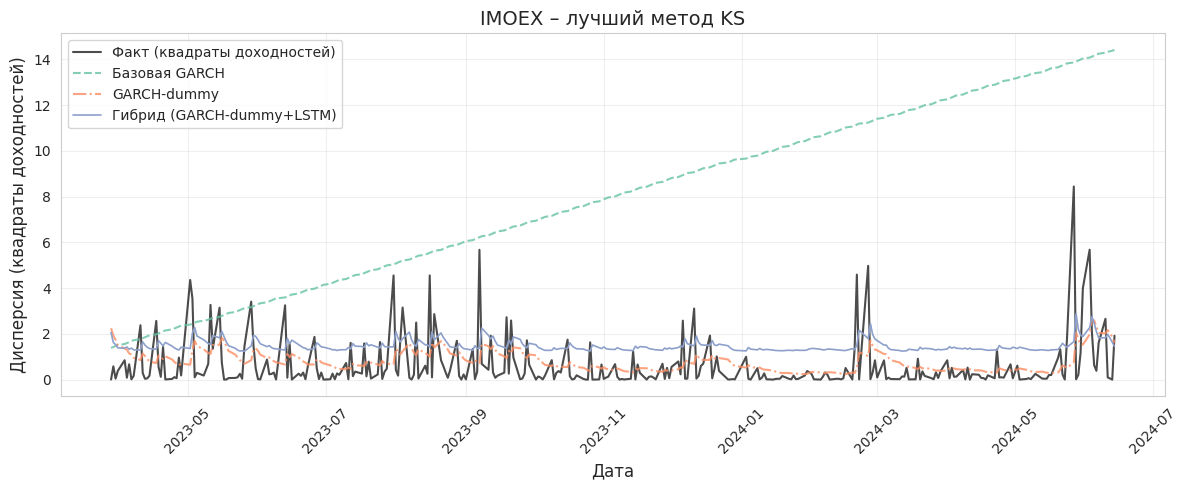

In [ ]:
def find_best_method(methods_dict):
    best_method = None
    best_rmse = np.inf
    for method_name, data in methods_dict.items():
        rmse = data['results']['GARCH-dummy']['RMSE']
        if rmse < best_rmse:
            best_rmse = rmse
            best_method = method_name
    return best_method, best_rmse

for ticker_name, methods_dict in all_results.items():
    best, best_rmse = find_best_method(methods_dict)
    print(f"\nДля {ticker_name} лучший метод (GARCH-dummy): {best.upper()} (RMSE={best_rmse:.4f})")
    data = methods_dict[best]
    dates = data['dates']
    act = data['actual']
    base = data['base']
    dummy = data['dummy']
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(dates, act, label='Факт (квадраты доходностей)', color='black', alpha=0.7, linewidth=1.5)
    ax.plot(dates, base, label='Базовая GARCH', linestyle='--', alpha=0.8)
    ax.plot(dates, dummy, label='GARCH-dummy', linestyle='-.', alpha=0.8)
    if data['hybrid'] is not None:
        ax.plot(dates, data['hybrid'], label='Гибрид (GARCH-dummy+LSTM)', linewidth=1.2)
    ax.set_title(f'{ticker_name} – лучший метод {best.upper()}', fontsize=14)
    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel('Дисперсия (квадраты доходностей)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    filename = f'{ticker_name}_{best}_forecast.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
rows = []
for ticker_name, methods_dict in all_results.items():
    for method_name, data in methods_dict.items():
        for model_name, metrics_vals in data['results'].items():
            rows.append({
                'Ticker': ticker_name,
                'Method': method_name.upper(),
                'Model': model_name,
                'RMSE': metrics_vals['RMSE'],
                'MAE': metrics_vals['MAE']
            })
df_results = pd.DataFrame(rows)
df_results.to_csv('forecast_results.csv', index=False)